In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

1st Task

In [2]:
!pip install pennylane
import pennylane as qml
from pennylane import numpy as np



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 49.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.9 MB/s eta 0:00:00:00:0100:01


In [4]:
dev=qml.device("default.qubit", wires=5)

In [11]:
@qml.qnode(dev)
def circuit():
    #Hadamard operation
    for i in range(5):
        qml.Hadamard(wires=i)
    
    #CNOT operation
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,4])

    #Swapping 0,4
    qml.SWAP(wires=[0,4])

    #Rotation around X
    qml.RX(np.pi/2, wires=3)

    return qml.state()



In [12]:
circuit()

array([0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j,
       0.125-0.125j, 0.125-0.125j, 0.125-0.125j, 0.125-0.125j])

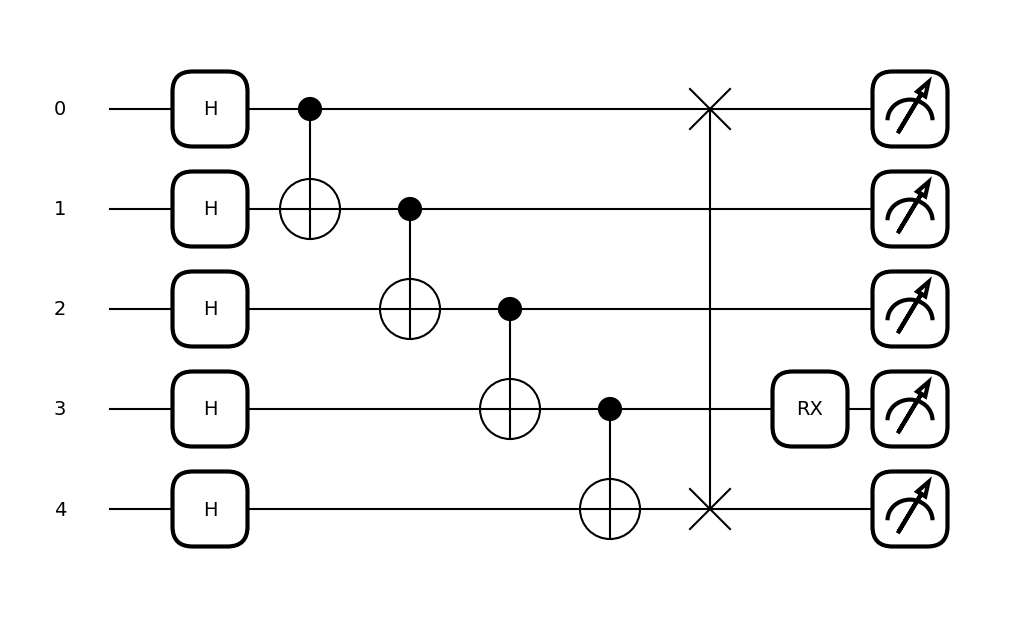

In [13]:
import matplotlib.pyplot  as plt

#plotting

drawer = qml.draw_mpl(circuit)
fig, ax = drawer()
plt.show()

2nd Task

In [14]:
@qml.qnode(dev)

def new_circuit():
    #Hadamard Gate to first qubit
    qml.Hadamard(wires=1)

    #Rotating second bit around X
    qml.RX(np.pi/3, wires=2)

    #Hadamard Gate to 4 th and 5th
    for i in range(3,5):
        qml.Hadamard(i)

    #Perform a swap test between the states of the first and second qubit |q1 q2> 
    #and the third and fourth qubit |q3 q4>
    ancilla = 4

    qml.Hadamard(wires=ancilla)

    qml.CSWAP(wires=[ancilla, 0, 2])
    qml.CSWAP(wires=[ancilla, 1, 3])

    qml.Hadamard(wires=ancilla)

    return qml.probs(wires=ancilla)

In [16]:
print(new_circuit())

[0.5 0.5]


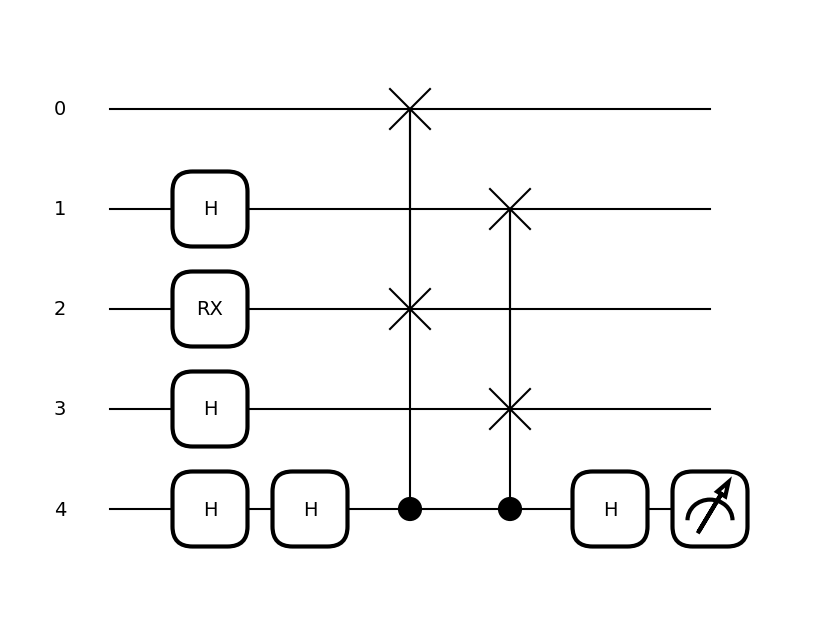

In [17]:
drawer = qml.draw_mpl(new_circuit)
fig, ax = drawer()
plt.show()